In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)

from randomness import *
from df_metrics import *
from simulation_exact import *
from utils import *
from data_analysis import *
from main import *
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from joblib import Parallel, delayed
from itertools import product

#seed = 42
#np.random.seed(seed)
#rng = np.random.default_rng(seed)

In [5]:
use_loss = 'hinge' #'log' or 'hinge' or 'squared_hinge' 
sigma_loss = 1.0 
c = 1.0 # choose c without scaling 
show_plots = False # set to True to see plots of the binary search
is_throw = True # set to True to throw out points outside margin --> only when loss is lipschitz. 
k = None # if none will be set based on data max norm
k_coef = 1.0 # coefficient to multiply k with
fit_intercept = True # whether to fit intercept in SVM model
ds = [2, 4, 8, 16, 32, 64] # dimensions to run experiments on
T = 200  # number of trials

In [6]:
def generate_gaus_data(n_pos, n_neg, mu_pos, mu_neg, sigma_pos, sigma_neg, rng, d=1):
    X_neg = rng.normal(loc=mu_neg, scale=sigma_neg, size=(n_neg, d)) # label -1 
    X_pos = rng.normal(loc=mu_pos, scale=sigma_pos, size=(n_pos, d)) # label 1 
    X = np.vstack([X_neg, X_pos])
    y = np.concatenate([-1 * np.ones(n_neg),np.ones(n_pos)])

    v = np.concatenate([np.ones(n_pos + n_neg)])  # generate_v_data(n_neg, n_pos, rng)
    return X, y, v

In [7]:
# choose parameters 
n_pos = 50 # number of data points in a sample with label 1
n_neg = 50 # number of data points in a sample with label -1
n_val_pos = 200
n_val_neg = 200
sigma_pos = 1.0
sigma_neg = 1.0
mus = np.linspace(3, 0, 31) # different sigmas to run the experiments on

In [14]:
# run exact sisigmalation
# returns df with cols "agent" | "true_v" | "critical_v" | "allocation" | "welfare" | "utility"
# utility = welfare - payment
# welfare = allocation * true_v
# critical_v = payment 

def compute_metrics_gaus_1(t):
    dfs = []
    for d in ds:
        for mu_scalar in mus:
            mu = np.concatenate(([mu_scalar], np.zeros(d - 1)))
            seed = hash((t, d, mu_scalar)) % (2**32)
            rng = np.random.default_rng(seed)
            x, y, v = generate_gaus_data(n_pos, n_neg, mu, -mu, sigma_pos/ np.sqrt(d), sigma_neg/ np.sqrt(d), rng, d)
            #x_val, y_val, _ = generate_gaus_data(n_val_pos, n_val_neg, mu, -mu, sigma_pos/ np.sqrt(d), sigma_neg/ np.sqrt(d), rng, d)
            
            df_exact, svm_model = run_exact(x, y, v, c, use_loss, sigma_loss=sigma_loss, plot=show_plots, 
                                    is_throw=is_throw, k=k, k_coef=k_coef, fit_intercept=fit_intercept)
            df_exact['t'] = t
            df_exact['d'] = d
            df_exact['mu'] = mu_scalar
            df_exact['k'] = np.linalg.norm(x, axis=1).max() if k is None else k
            #df_exact['valid_acc'] = svm_model.score(x_val,y_val)
            df_exact['label'] = y[df_exact['agent'].astype(int)]
            dfs.append(df_exact)

    return pd.concat(dfs, ignore_index=True)

In [15]:
mega_df_mu = pd.concat(  
    Parallel(n_jobs=-1, backend="loky")(
        delayed(compute_metrics_gaus_1)(t) for t in range(T)
        ), 
        ignore_index=True
)

In [ ]:
#without normlization
mega_df_mu2 = pd.concat(  
    Parallel(n_jobs=-1, backend="loky")(
        delayed(compute_metrics_gaus_1)(t) for t in range(T)
        ), 
        ignore_index=True
)

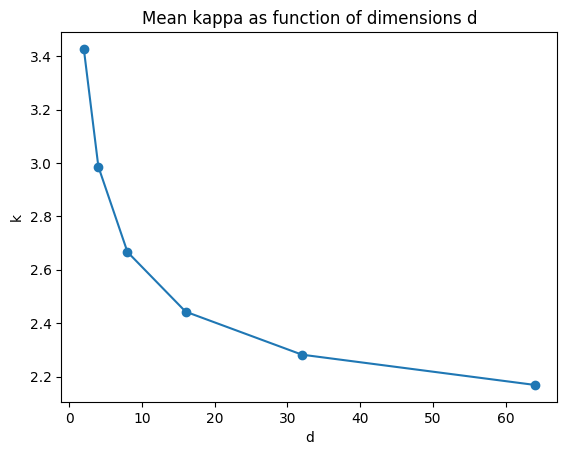

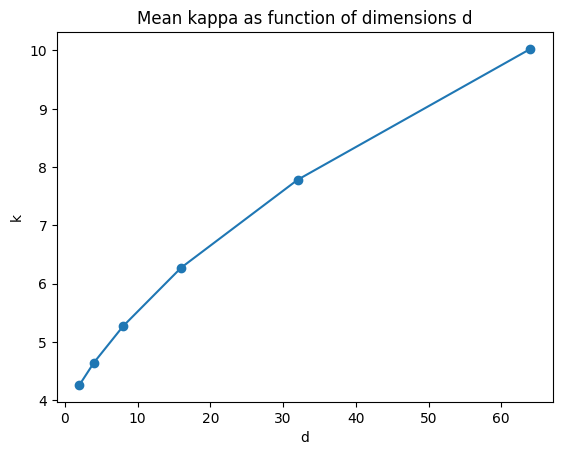

In [16]:
plot_mean_kappa(mega_df_mu, labels = [1,-1])
plot_mean_kappa(mega_df_mu2, labels = [1,-1])

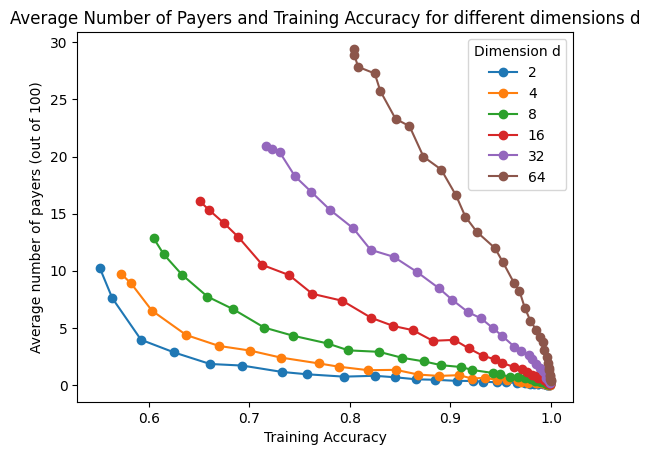

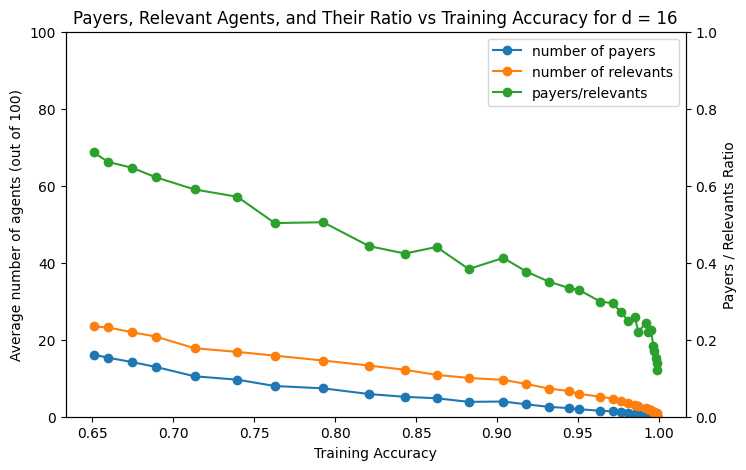

In [22]:
acc_num_payers(mega_df_mu2, 'mu', T, labels = [1, -1])
acc_2(mega_df_mu2, 'mu', T, [16], labels = [1, -1])

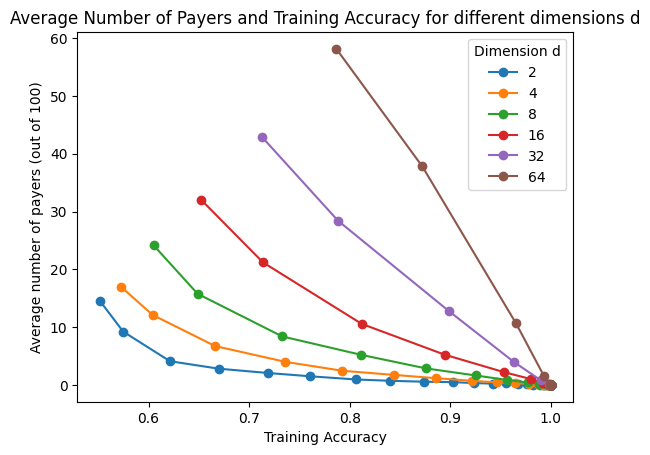

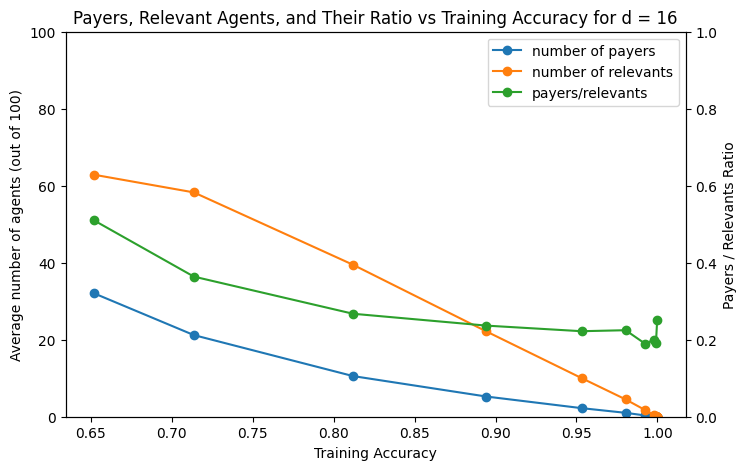

In [21]:
acc_num_payers(mega_df_mu, 'mu', T, labels = [1, -1])
acc_2(mega_df_mu, 'mu', T, [16], labels = [1, -1])

In [27]:
mean_num_payers = (
                        mega_df_mu[(mega_df_mu['label'].isin([1,-1])) 
                                   & (mega_df_mu['d'].isin(ds))
                                   & (mega_df_mu['mu'] > 0.1)
                                   & (mega_df_mu['mu'] <= 0.2)]
                        .assign(pos=lambda df: df['critical_v'] > 0)
                        .groupby(['mu', 'd'])['pos']
                        .sum()
                        .unstack('d', fill_value=0)
                        / T
                    )
mean_num_payers2 = (
                        mega_df_mu2[(mega_df_mu2['label'].isin([1,-1])) 
                                    & (mega_df_mu2['d'].isin(ds))
                                     & (mega_df_mu['mu'] > 0.1)
                                   & (mega_df_mu['mu'] <= 0.2)]
                        .assign(pos=lambda df: df['critical_v'] > 0)
                        .groupby(['mu', 'd'])['pos']
                        .sum()
                        .unstack('d', fill_value=0)
                        / T
                    )

In [28]:
mean_num_payers

d,2,4,8,16,32,64
mu,,,,,,
0.2,4.105,6.73,8.39,10.555,12.805,10.7


In [29]:
mean_num_payers2

d,2,4,8,16,32,64
mu,,,,,,
0.2,3.955,6.51,9.65,14.19,20.39,27.855
